In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from WBUtiles.WBClean import clean_wb_wide
from WBUtiles.WBSummary import summary_wb, plot_missing_heatmap
from WBUtiles.WBLatex import make_lookup_latex, make_summary_latex
from notebooks.lic_eco_perform import df_zambia

sns.set_theme(
    style="whitegrid",     # clean academic look
    context="paper",       # scales text for papers
    font_scale=1.1
)

In [3]:
zambia_gov = pd.read_csv('../data/Zambia_Government Role/gov_role_perform.csv')
lic_gov = pd.read_csv('../data/LIC_GovernmentRole/gov_role_perform.csv')

In [4]:
zambia_clean, zambia_lookup = clean_wb_wide(zambia_gov, drop_top_rows=0)
lic_clean, lic_lookup = clean_wb_wide(lic_gov, drop_top_rows=0)

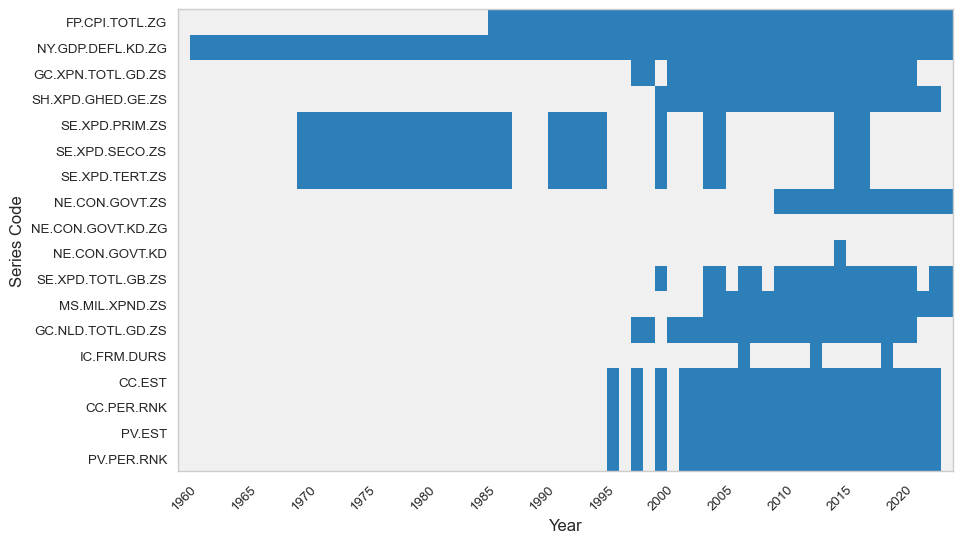

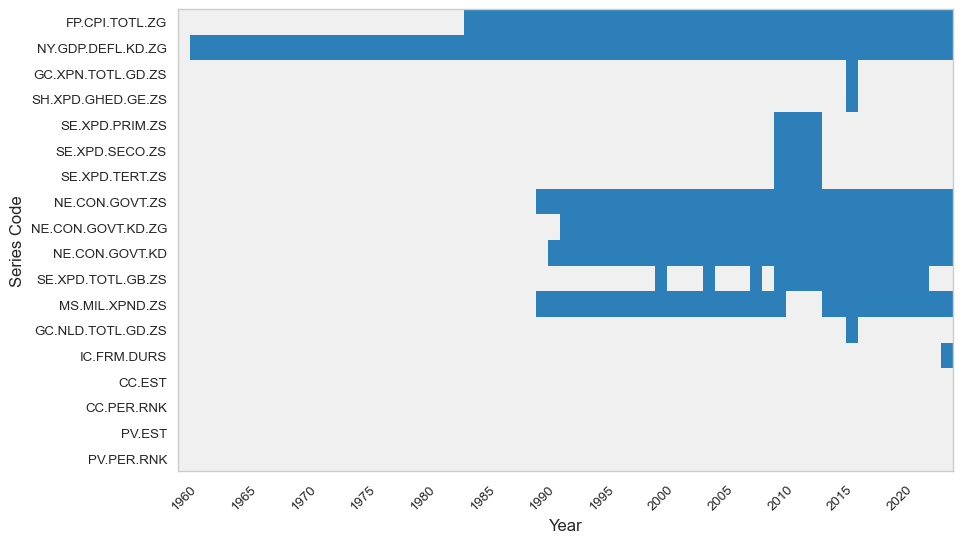

In [5]:
availability_zambia, fig_zambia, ax_zambia = plot_missing_heatmap(
    zambia_clean,
    lookup=zambia_lookup
)
availability_lic, fig_lic, ax_lic = plot_missing_heatmap(
    lic_clean,
    lookup=lic_lookup
)

In [18]:
zambia_lookup

,Series Code,Series Name
0,FP.CPI.TOTL.ZG,"Inflation, consumer prices (annual %)"
1,NY.GDP.DEFL.KD.ZG,"Inflation, GDP deflator (annual %)"
2,GC.XPN.TOTL.GD.ZS,Expense (% of GDP)
3,SH.XPD.GHED.GE.ZS,Domestic general government health expenditure...
4,SE.XPD.PRIM.ZS,Expenditure on primary education (% of governm...
5,SE.XPD.SECO.ZS,Expenditure on secondary education (% of gover...
6,SE.XPD.TERT.ZS,Expenditure on tertiary education (% of govern...
7,NE.CON.GOVT.ZS,General government final consumption expenditu...
8,NE.CON.GOVT.KD.ZG,General government final consumption expenditu...
9,NE.CON.GOVT.KD,General government final consumption expenditu...


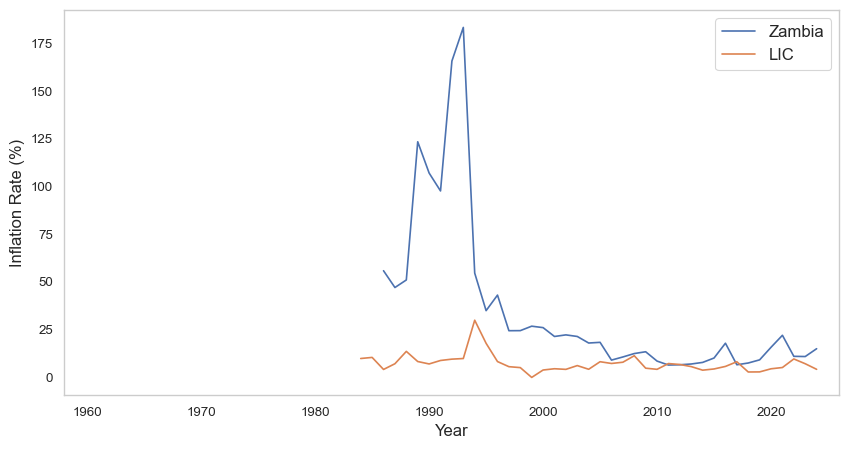

In [15]:
# CPI
df_lic = lic_clean
df_zambia = zambia_clean
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_zambia['Year'], df_zambia['FP.CPI.TOTL.ZG'], label='Zambia')
ax.plot(df_lic['Year'], df_lic['FP.CPI.TOTL.ZG'], label='LIC')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Inflation Rate (%)', fontsize=12)
ax.set_xlim(1958, 2026)

ax.grid(False)
ax.legend(fontsize=12)

fig.savefig(
    "../figures/LIC/gov_role/CPI_lic_zambia.pdf",
    format="pdf",
    bbox_inches="tight"
)

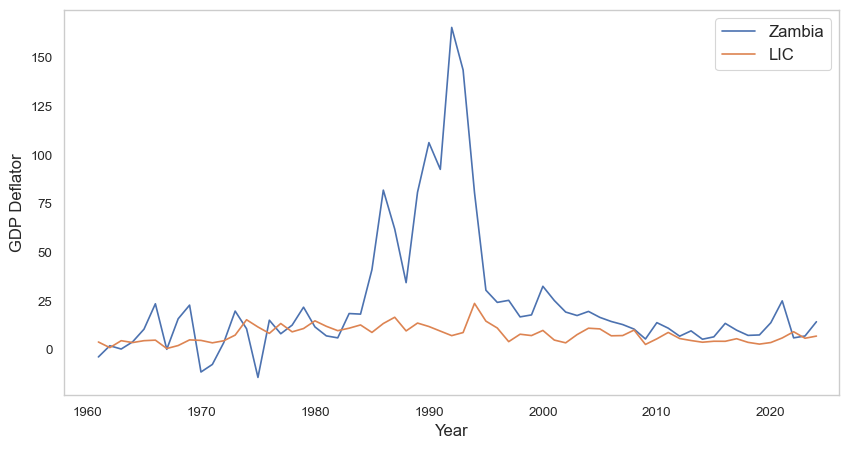

In [17]:
# GDP Deflator
df_lic = lic_clean
df_zambia = zambia_clean
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_zambia['Year'], df_zambia['NY.GDP.DEFL.KD.ZG'], label='Zambia')
ax.plot(df_lic['Year'], df_lic['NY.GDP.DEFL.KD.ZG'], label='LIC')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('GDP Deflator', fontsize=12)
ax.set_xlim(1958, 2026)

ax.grid(False)
ax.legend(fontsize=12)

fig.savefig(
    "../figures/LIC/gov_role/GDP_deflator_lic_zambia.pdf",
    format="pdf",
    bbox_inches="tight"
)

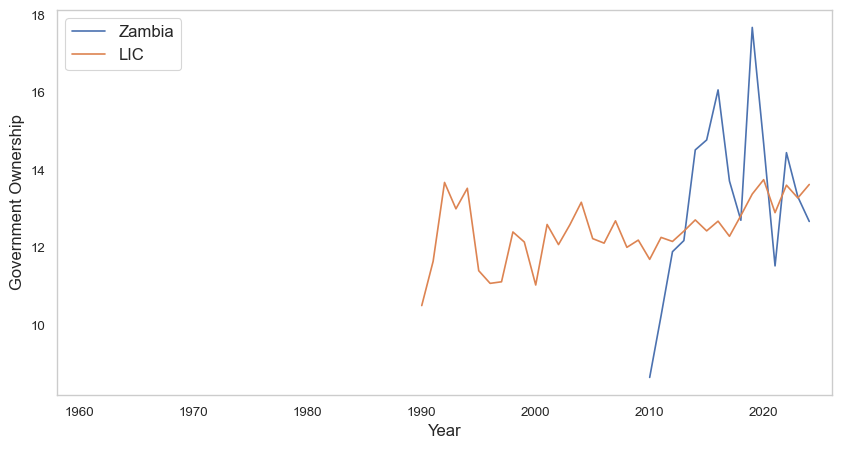

In [21]:
# General government final consumption expenditure (% of GDP)
df_lic = lic_clean
df_zambia = zambia_clean
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_zambia['Year'], df_zambia['NE.CON.GOVT.ZS'], label='Zambia')
ax.plot(df_lic['Year'], df_lic['NE.CON.GOVT.ZS'], label='LIC')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Government Ownership', fontsize=12)
ax.set_xlim(1958, 2026)

ax.grid(False)
ax.legend(fontsize=12)
fig.savefig(
    "../figures/LIC/gov_role/gov_final_exp_lic_zambia.pdf",
    format="pdf",
    bbox_inches="tight")

In [27]:
df = zambia_clean[['Year','IC.FRM.DURS']].dropna()
df

,Year,IC.FRM.DURS
47,2007,48.283409
53,2013,23.614454
59,2019,20.007380


In [28]:
print(df[['Year', 'IC.FRM.DURS']].to_latex(index=False, caption='Duration to Obtain Business License (Zambia)', label='tab:business_license_duration'))

\begin{table}
\caption{Duration to Obtain Business License (Zambia)}
\label{tab:business_license_duration}
\begin{tabular}{rr}
\toprule
Year & IC.FRM.DURS \\
\midrule
2007 & 48.283409 \\
2013 & 23.614454 \\
2019 & 20.007380 \\
\bottomrule
\end{tabular}
\end{table}



In [29]:
df = lic_clean[['Year','IC.FRM.DURS']].dropna()
df

,Year,IC.FRM.DURS
64,2024,13.662523


In [31]:
print(df[['Year', 'IC.FRM.DURS']].to_latex(index=False, caption='Duration to Obtain Business License (LIC)', label='tab:business_license_duration_lic'))

\begin{table}
\caption{Duration to Obtain Business License (LIC)}
\label{tab:business_license_duration_lic}
\begin{tabular}{rr}
\toprule
Year & IC.FRM.DURS \\
\midrule
2024 & 13.662523 \\
\bottomrule
\end{tabular}
\end{table}

